In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# Global contour maps for mean temperature and precipitation
# Data source: missing-value & outlier processed dataset

import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    !pip install cartopy -q
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

In [14]:
# Find the cleaned full weather dataset

BASE_DIR = "/content/drive/MyDrive/Weather Trend Forecasting"
csv_candidates = []
for root, dirs, files in os.walk(BASE_DIR):
    for f in files:
        if f.endswith(".csv"):
            path = os.path.join(root, f)
            name = f.lower()
            score = 0
            if "globalweatherrepository" in name:
                score += 5
            if "outlier" in name:
                score += 4
            if "cleaned" in name:
                score += 4
            if "processed" in name:
                score += 2
            if "city" in name or "cities" in name:
                score -= 5
            if "prediction" in root.lower():
                score -= 2
            csv_candidates.append({
                "path": path,
                "file": f,
                "score": score
            })

candidates_df = pd.DataFrame(csv_candidates).sort_values(
    "score",
    ascending=False
)

display(candidates_df.head(20))
CLEANED_FILE = candidates_df.iloc[0]["path"]
print("Selected CLEANED_FILE:")
print(CLEANED_FILE)
df = pd.read_csv(CLEANED_FILE)
print("Data shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
display(df.head())

,path,file,score
522,/content/drive/MyDrive/Weather Trend Forecasti...,GlobalWeatherRepository_missing_outlier_cleane...,13
4,/content/drive/MyDrive/Weather Trend Forecasti...,GlobalWeatherRepository_missing_cleaned.csv,9
778,/content/drive/MyDrive/Weather Trend Forecasti...,Zagreb_outlier_cleaned.csv,8
777,/content/drive/MyDrive/Weather Trend Forecasti...,Yangon_outlier_cleaned.csv,8
776,/content/drive/MyDrive/Weather Trend Forecasti...,Yaren_outlier_cleaned.csv,8
779,/content/drive/MyDrive/Weather Trend Forecasti...,Yerevan_outlier_cleaned.csv,8
774,/content/drive/MyDrive/Weather Trend Forecasti...,Washington_Park_outlier_cleaned.csv,8
773,/content/drive/MyDrive/Weather Trend Forecasti...,Windhoek_outlier_cleaned.csv,8
772,/content/drive/MyDrive/Weather Trend Forecasti...,Warsaw_outlier_cleaned.csv,8
771,/content/drive/MyDrive/Weather Trend Forecasti...,Wellington_outlier_cleaned.csv,8


Selected CLEANED_FILE:
/content/drive/MyDrive/Weather Trend Forecasting/processed_outputs/outlier_processed_outputs/GlobalWeatherRepository_missing_outlier_cleaned.csv
Data shape: (141508, 41)
Columns:
['last_updated', 'country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


,last_updated,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,2024-05-31 16:15:00,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717164900,16.0,60.8,Moderate rain,...,2.2,3.4,1,1,05:36 AM,09:52 PM,02:59 AM,02:09 PM,Waning Crescent,47
1,2024-06-01 16:30:00,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717252200,16.0,60.8,Overcast,...,6.5,19.6,1,1,05:35 AM,09:53 PM,03:12 AM,03:34 PM,Waning Crescent,35
2,2024-06-04 16:15:00,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717510500,18.0,64.4,Partly cloudy,...,5.7,6.0,1,1,05:33 AM,09:56 PM,03:56 AM,07:57 PM,Waning Crescent,8
3,2024-06-05 16:15:00,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717596900,15.0,59.0,Partly cloudy,...,1.2,2.4,1,1,05:33 AM,09:56 PM,04:17 AM,09:25 PM,Waning Crescent,3
4,2024-06-11 16:15:00,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1718115300,15.2,59.4,Partly cloudy,...,0.5,0.9,1,1,05:30 AM,10:01 PM,10:16 AM,01:31 AM,Waxing Crescent,21


In [15]:
# Column detection

def find_col(possible_names, columns):
    col_map = {c.lower(): c for c in columns}
    for name in possible_names:
        if name.lower() in col_map:
            return col_map[name.lower()]

    for c in columns:
        c_low = c.lower()
        for name in possible_names:
            if name.lower() in c_low:
                return c

    return None


country_col = find_col(
    ["country", "country_name"],
    df.columns
)

city_col = find_col(
    ["location_name", "city", "location", "name"],
    df.columns
)

lat_col = find_col(
    ["latitude", "lat"],
    df.columns
)

lon_col = find_col(
    ["longitude", "lon", "lng"],
    df.columns
)

temp_col = find_col(
    ["temperature_celsius", "temperature", "temp_c", "temp"],
    df.columns
)

precip_col = find_col(
    ["precip_mm", "precipitation_mm", "precipitation", "rainfall", "rain_mm", "precip"],
    df.columns
)

print("country_col:", country_col)
print("city_col:", city_col)
print("lat_col:", lat_col)
print("lon_col:", lon_col)
print("temp_col:", temp_col)
print("precip_col:", precip_col)
required = {
    "city_col": city_col,
    "lat_col": lat_col,
    "lon_col": lon_col,
    "temp_col": temp_col,
    "precip_col": precip_col
}

missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

country_col: country
city_col: location_name
lat_col: latitude
lon_col: longitude
temp_col: temperature_celsius
precip_col: precip_mm


In [23]:
# Build city-level mean temperature and precipitation
# Correct version: group by country + city only

df_clean = df.copy()
for col in [lat_col, lon_col, temp_col, precip_col]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean = df_clean.dropna(
    subset=[country_col, city_col, lat_col, lon_col, temp_col, precip_col]
)

df_clean = df_clean[
    (df_clean[lat_col] >= -90) &
    (df_clean[lat_col] <= 90) &
    (df_clean[lon_col] >= -180) &
    (df_clean[lon_col] <= 180)
].copy()

city_mean_df = (
    df_clean
    .groupby([country_col, city_col], as_index=False)
    .agg(
        latitude=(lat_col, "mean"),
        longitude=(lon_col, "mean"),
        mean_temperature_celsius=(temp_col, "mean"),
        mean_precipitation=(precip_col, "mean"),
        record_count=(temp_col, "count")
    )
)

# Rename for consistency
city_mean_df = city_mean_df.rename(
    columns={
        country_col: "country",
        city_col: "location_name"
    }
)
lat_col = "latitude"
lon_col = "longitude"
print("Correct city mean data shape:", city_mean_df.shape)
print("Unique city count:", city_mean_df[["country", "location_name"]].drop_duplicates().shape[0])
print("Unique coordinate points:", city_mean_df[[lat_col, lon_col]].drop_duplicates().shape[0])
display(city_mean_df.head())

Correct city mean data shape: (270, 7)
Unique city count: 270
Unique coordinate points: 268


,country,location_name,latitude,longitude,mean_temperature_celsius,mean_precipitation,record_count
0,Afghanistan,Kabul,34.517330,69.182670,18.858379,0.037074,728
1,Albania,Tirana,41.327979,19.819111,19.185950,0.140964,726
2,Algeria,Algiers,36.762510,3.050486,20.196552,0.051724,725
3,Andorra,Andorra La Vella,42.500000,1.517331,8.647593,0.122435,727
4,Angola,Luanda,-8.838625,13.233559,26.081155,0.034402,727


In [24]:
# Save aggregated city-level data

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "eda_outputs",
    "global_temperature_precipitation_contours"
)

FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
DATA_DIR = os.path.join(OUTPUT_DIR, "data")

for p in [OUTPUT_DIR, FIG_DIR, DATA_DIR]:
    os.makedirs(p, exist_ok=True)

city_mean_path = os.path.join(
    DATA_DIR,
    "city_mean_temperature_precipitation.csv"
)

city_mean_df.to_csv(
    city_mean_path,
    index=False
)

print("Saved city mean data:")
print(city_mean_path)

Saved city mean data:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/data/city_mean_temperature_precipitation.csv


In [25]:
# Interpolation helper

from scipy.spatial import cKDTree
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

def make_global_grid(
    data_df,
    value_col,
    grid_res=1.0,
    smooth_sigma=1.0,
    max_distance_deg=18
):
    lons = data_df[lon_col].values.astype(float)
    lats = data_df[lat_col].values.astype(float)
    values = data_df[value_col].values.astype(float)
    lon_grid = np.arange(-180, 180 + grid_res, grid_res)
    lat_grid = np.arange(-60, 80 + grid_res, grid_res)
    grid_lon, grid_lat = np.meshgrid(lon_grid, lat_grid)
    points = np.column_stack([lons, lats])

    grid_values = griddata(
        points,
        values,
        (grid_lon, grid_lat),
        method="linear"
    )

    nearest_values = griddata(
        points,
        values,
        (grid_lon, grid_lat),
        method="nearest"
    )

    tree = cKDTree(points)
    dist, _ = tree.query(
        np.column_stack([grid_lon.ravel(), grid_lat.ravel()])
    )
    dist = dist.reshape(grid_lon.shape)
    grid_values = np.where(
        np.isnan(grid_values) & (dist <= max_distance_deg),
        nearest_values,
        grid_values
    )

    grid_values = np.where(
        dist > max_distance_deg,
        np.nan,
        grid_values
    )

    if smooth_sigma is not None and smooth_sigma > 0:
        valid_mask = np.isfinite(grid_values)
        filled = np.where(valid_mask, grid_values, 0)
        weights = valid_mask.astype(float)
        smoothed = gaussian_filter(filled, sigma=smooth_sigma)
        smoothed_weights = gaussian_filter(weights, sigma=smooth_sigma)
        grid_values = smoothed / np.maximum(smoothed_weights, 1e-6)
        grid_values[smoothed_weights < 0.2] = np.nan
    return grid_lon, grid_lat, grid_values

In [48]:
# Plot helper

def plot_contour_world_map(
    data_df,
    value_col,
    title,
    colorbar_label,
    output_filename,
    cmap,
    levels=24,
    grid_res=1.0,
    smooth_sigma=1.0,
    point_color="black"
):
    grid_lon, grid_lat, grid_values = make_global_grid(
        data_df=data_df,
        value_col=value_col,
        grid_res=grid_res,
        smooth_sigma=smooth_sigma
    )
    fig = plt.figure(figsize=(18, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_global()

    # Black-white world map background
    ax.add_feature(
        cfeature.OCEAN,
        facecolor="white",
        zorder=0
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="white",
        edgecolor="black",
        linewidth=0.4,
        zorder=0
    )

    ax.add_feature(
        cfeature.COASTLINE,
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    ax.add_feature(
        cfeature.BORDERS,
        edgecolor="black",
        linewidth=0.35,
        zorder=3
    )

    vmin = np.nanpercentile(grid_values, 5)
    vmax = np.nanpercentile(grid_values, 95)

    grid_values_plot = np.clip(
        grid_values,
        vmin,
        vmax
    )

    contour = ax.contourf(
        grid_lon,
        grid_lat,
        grid_values_plot,
        levels=levels,
        cmap=cmap,
        alpha=0.78,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

    contour_lines = ax.contour(
        grid_lon,
        grid_lat,
        grid_values_plot,
        levels=10,
        colors="black",
        linewidths=0.28,
        alpha=0.45,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.clabel(
        contour_lines,
        inline=True,
        fontsize=7,
        fmt="%.1f"
    )

    ax.scatter(
        data_df[lon_col],
        data_df[lat_col],
        s=10,
        c=point_color,
        alpha=0.55,
        transform=ccrs.PlateCarree(),
        zorder=4,
        label="Cities"
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        color="gray",
        alpha=0.45,
        linestyle="--"
    )

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        contour,
        ax=ax,
        orientation="horizontal",
        pad=0.055,
        shrink=0.85
    )

    cbar.set_label(
        colorbar_label,
        fontsize=12
    )

    ax.set_title(
        title,
        fontsize=17,
        pad=18
    )

    ax.legend(
        loc="lower left",
        frameon=True
    )

    plt.tight_layout()

    save_path = os.path.join(
        FIG_DIR,
        output_filename
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    print("Saved figure:")
    print(save_path)

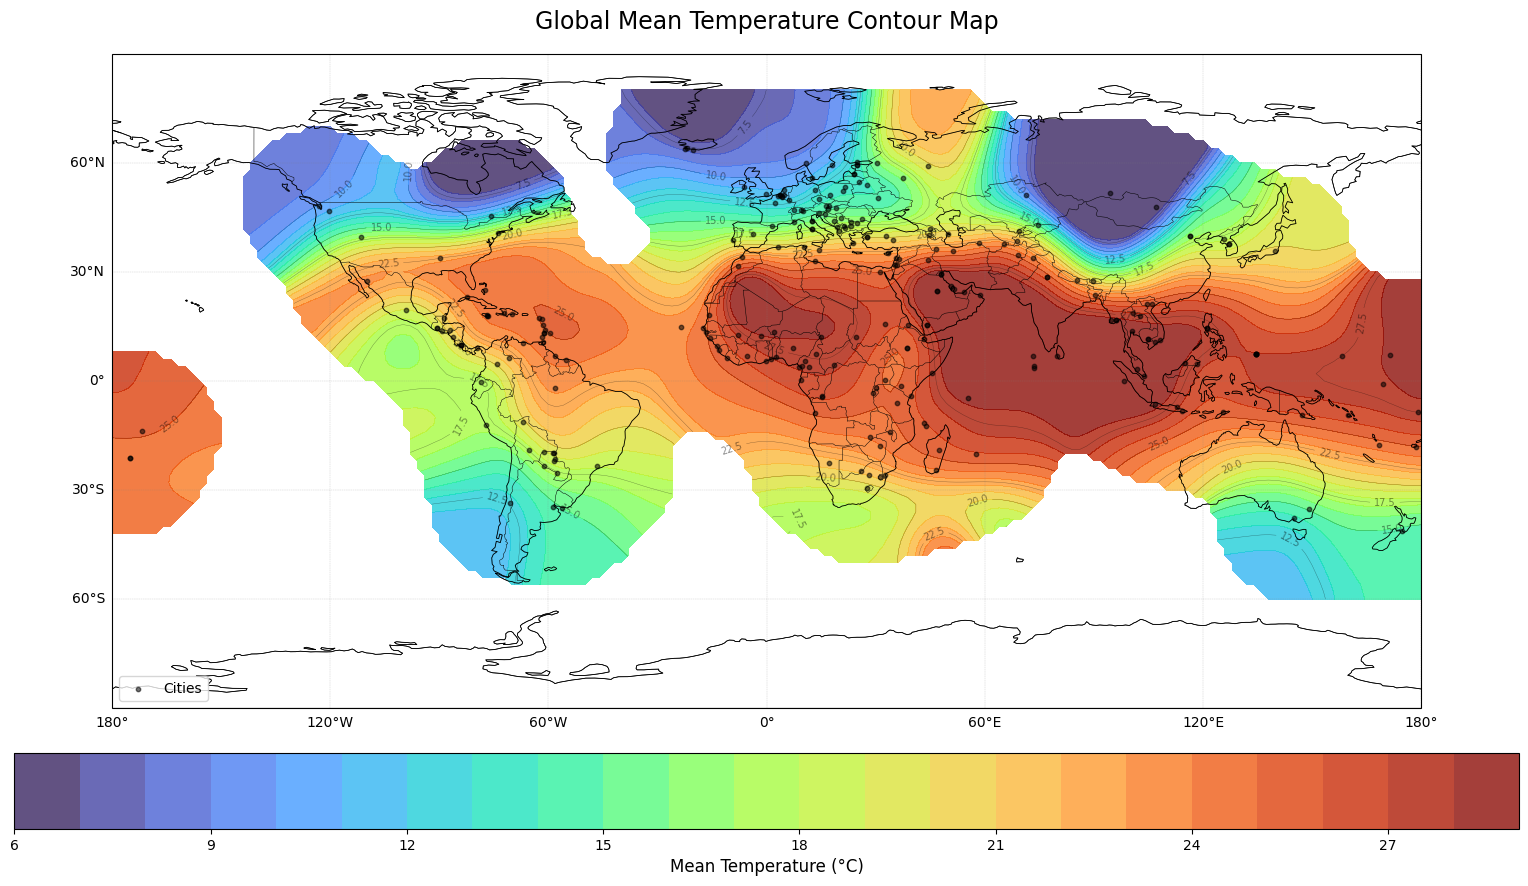

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_mean_temperature_contour_map.png


In [56]:
# Mean temperature contour map

plot_contour_world_map(
    data_df=city_mean_df,
    value_col="mean_temperature_celsius",
    title="Global Mean Temperature Contour Map",
    colorbar_label="Mean Temperature (°C)",
    output_filename="global_mean_temperature_contour_map.png",
    cmap="turbo",
    levels=26,
    grid_res=2.0,
    smooth_sigma=3.0,
    point_color="black"
)

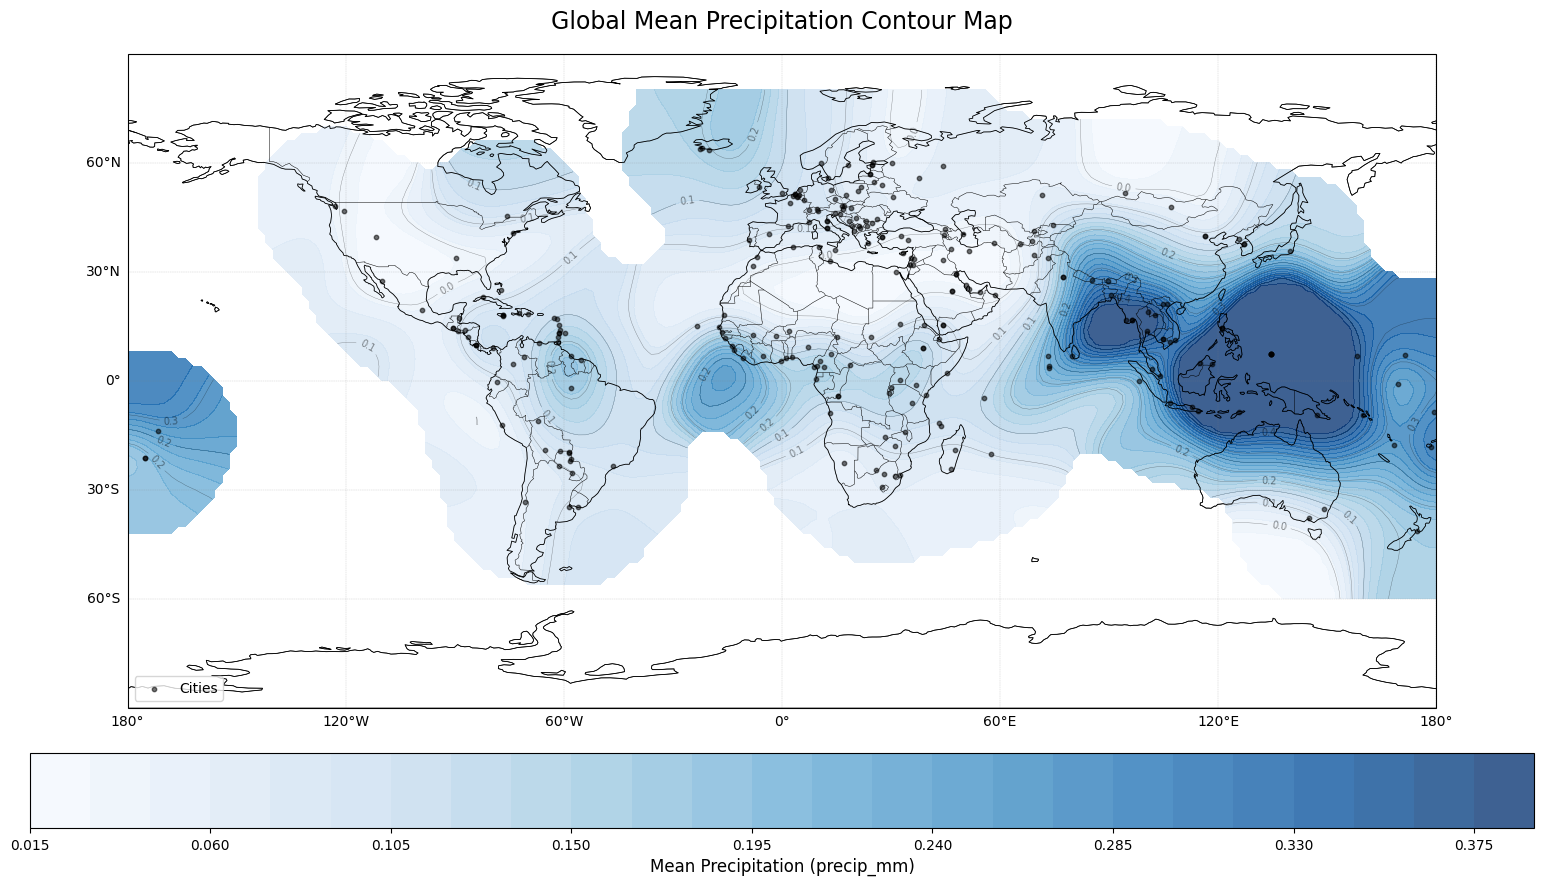

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_mean_precipitation_contour_map.png


In [57]:
# Mean precipitation contour map

plot_contour_world_map(
    data_df=city_mean_df,
    value_col="mean_precipitation",
    title="Global Mean Precipitation Contour Map",
    colorbar_label=f"Mean Precipitation ({precip_col})",
    output_filename="global_mean_precipitation_contour_map.png",
    cmap="Blues",
    levels=26,
    grid_res=2.0,
    smooth_sigma=3.0,
    point_color="black"
)

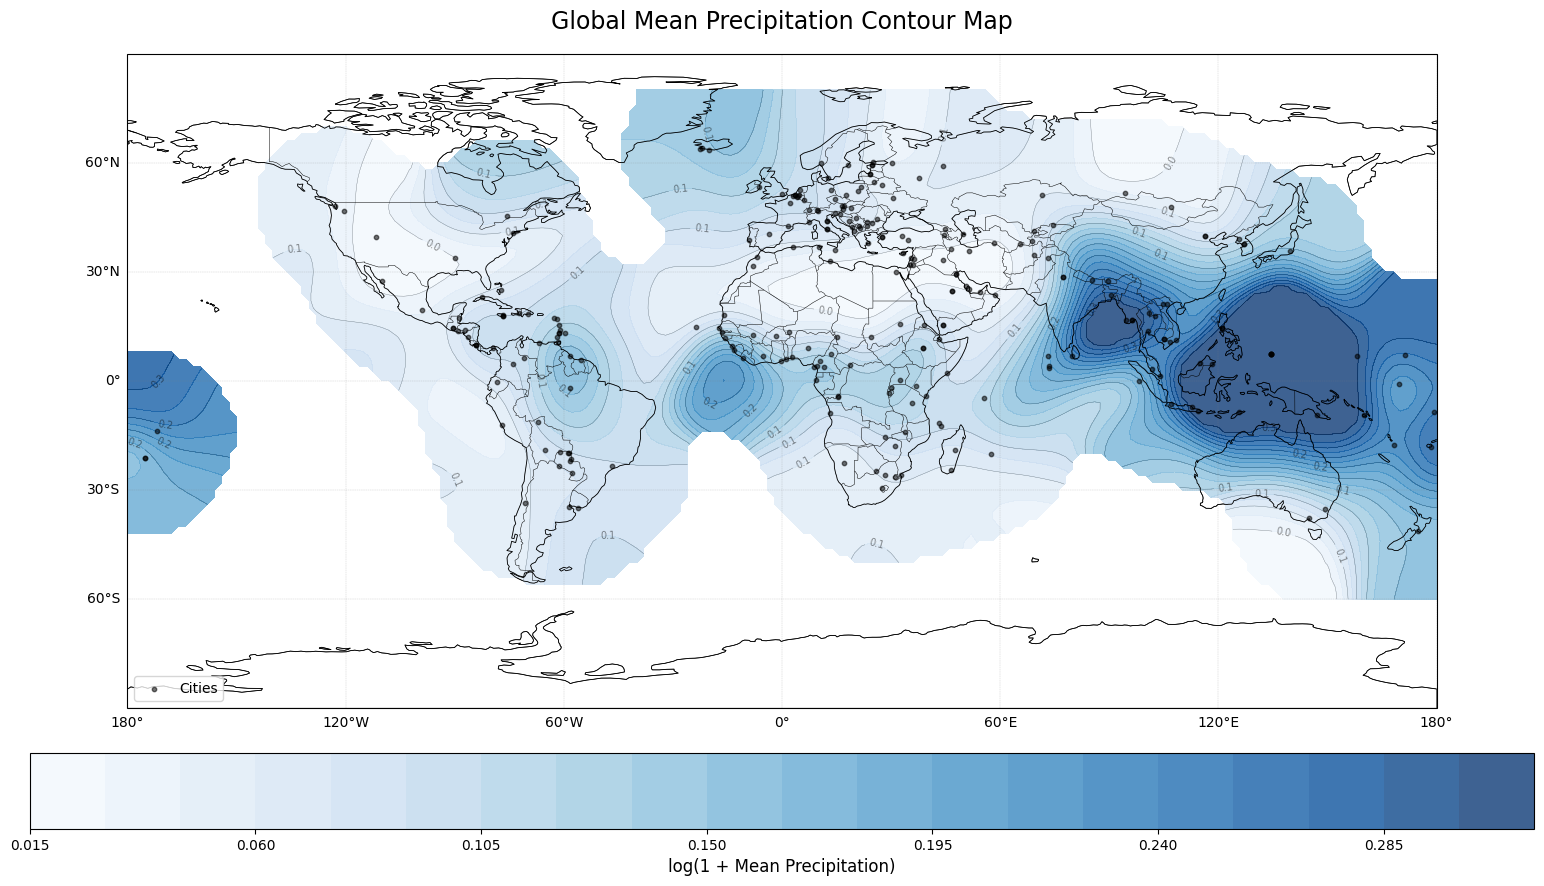

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_mean_precipitation_contour_map_log1p.png


In [58]:
city_mean_df["mean_precipitation_log1p"] = np.log1p(
    city_mean_df["mean_precipitation"]
)

plot_contour_world_map(
    data_df=city_mean_df,
    value_col="mean_precipitation_log1p",
    title="Global Mean Precipitation Contour Map",
    colorbar_label="log(1 + Mean Precipitation)",
    output_filename="global_mean_precipitation_contour_map_log1p.png",
    cmap="Blues",
    levels=24,
    grid_res=2.0,
    smooth_sigma=3.0,
    point_color="black"
)

In [59]:
equator_df = city_mean_df[city_mean_df["latitude"].between(-15, 15)].copy()
display(
    equator_df.sort_values(
        "mean_precipitation",
        ascending=False
    ).head(50)
)

,country,location_name,latitude,longitude,mean_temperature_celsius,mean_precipitation,record_count,mean_precipitation_log1p
245,USA United States of America,Palau,7.500000,134.570000,27.200000,1.590000,1,0.951658
144,Malásia,Ivory Ivory Ban,4.630000,118.370000,24.300000,1.550000,1,0.936093
101,Indonesia,Laos,-8.182106,114.319028,26.400551,0.664628,726,0.509602
40,Cameroon,Bafoussam,5.470000,10.420000,22.677778,0.663333,18,0.508824
138,Malaysia,Kuala Lumpur,3.167332,101.700000,30.485124,0.589091,726,0.463162
176,Papua New Guinea,Port Moresby,-9.463808,147.192025,26.893260,0.492779,727,0.400639
31,Brunei Darussalam,Bandar Seri Begawan,4.882672,114.932672,29.451586,0.490952,725,0.399415
209,Sierra Leone,Freetown,8.490000,-13.233405,25.908840,0.460580,724,0.378834
89,Guyana,Georgetown,6.800000,-58.167334,24.583956,0.448105,723,0.370256
213,Solomon Islands,Honiara,-9.432669,159.950000,27.338102,0.430633,727,0.358117


In [31]:
america_africa_equator = city_mean_df[
    city_mean_df["latitude"].between(-15, 15)
    & (
        city_mean_df["longitude"].between(-90, -30)
        | city_mean_df["longitude"].between(-20, 50)
    )
].copy()

display(
    america_africa_equator.sort_values(
        "mean_precipitation",
        ascending=False
    )
)

,country,location_name,latitude,longitude,mean_temperature_celsius,mean_precipitation,record_count,mean_precipitation_log1p
40,Cameroon,Bafoussam,5.470000,10.420000,22.677778,0.663333,18,0.508824
209,Sierra Leone,Freetown,8.490000,-13.233405,25.908840,0.460580,724,0.378834
89,Guyana,Georgetown,6.800000,-58.167334,24.583956,0.448105,723,0.370256
87,Guinea,Conakry,9.509353,-13.711779,26.118044,0.370234,726,0.314982
75,Ethiopia,Addis Abeba,9.030000,38.700000,19.800000,0.340000,1,0.292670
...,...,...,...,...,...,...,...,...
51,Colombia,Bogota,4.600000,-74.080000,13.500000,0.020000,1,0.019803
219,Sudan,Juba,12.150000,24.450000,28.336138,0.014124,725,0.014025
184,Peru,Lima,-12.050000,-77.050000,18.042382,0.004030,722,0.004022
119,Komoren,Moroni,-12.350000,43.850000,25.200000,0.000000,1,0.000000


In [60]:
# Additional global contour analysis:
# 1. Count unique location_name
# 2. For cities with sequence length > 100:
#    temporal variability of temperature and precipitation
# 3. For all cities:
#    mean wind_kph, humidity, PM2.5
# 4. For cities with sequence length > 100:
#    temporal variability of wind_kph, humidity, PM2.5

import os
import numpy as np
import pandas as pd

# Column detection helper
def find_col(possible_names, columns):
    col_map = {c.lower(): c for c in columns}

    for name in possible_names:
        if name.lower() in col_map:
            return col_map[name.lower()]

    for c in columns:
        c_low = c.lower()
        for name in possible_names:
            if name.lower() in c_low:
                return c

    return None


# Detect required columns
country_col = find_col(
    ["country", "country_name"],
    df.columns
)

city_col = find_col(
    ["location_name", "city", "location"],
    df.columns
)

lat_original_col = find_col(
    ["latitude", "lat"],
    df.columns
)

lon_original_col = find_col(
    ["longitude", "lon", "lng"],
    df.columns
)

temp_col = find_col(
    ["temperature_celsius", "temperature", "temp_c", "temp"],
    df.columns
)

precip_col = find_col(
    ["precip_mm", "precipitation_mm", "precipitation", "rainfall", "rain_mm", "precip"],
    df.columns
)

wind_col = find_col(
    ["wind_kph", "wind_speed_kph", "wind", "wind_speed"],
    df.columns
)

humidity_col = find_col(
    ["humidity", "relative_humidity"],
    df.columns
)

pm25_col = find_col(
    ["air_quality_PM2.5", "pm2_5", "pm25", "pm2.5", "air_quality_pm2_5"],
    df.columns
)

time_col = find_col(
    ["last_updated", "time", "datetime", "date"],
    df.columns
)

print("country_col:", country_col)
print("city_col:", city_col)
print("lat_original_col:", lat_original_col)
print("lon_original_col:", lon_original_col)
print("temp_col:", temp_col)
print("precip_col:", precip_col)
print("wind_col:", wind_col)
print("humidity_col:", humidity_col)
print("pm25_col:", pm25_col)
print("time_col:", time_col)

required_cols = [
    country_col,
    city_col,
    lat_original_col,
    lon_original_col,
    temp_col,
    precip_col,
    wind_col,
    humidity_col,
    pm25_col
]

if any(c is None for c in required_cols):
    raise ValueError("Some required columns were not found. Please check printed column names.")

country_col: country
city_col: location_name
lat_original_col: latitude
lon_original_col: longitude
temp_col: temperature_celsius
precip_col: precip_mm
wind_col: wind_kph
humidity_col: humidity
pm25_col: air_quality_PM2.5
time_col: last_updated


In [61]:
# Clean base dataframe

df_work = df.copy()
numeric_cols = [
    lat_original_col,
    lon_original_col,
    temp_col,
    precip_col,
    wind_col,
    humidity_col,
    pm25_col
]

for col in numeric_cols:
    df_work[col] = pd.to_numeric(
        df_work[col],
        errors="coerce"
    )

df_work = df_work.dropna(
    subset=[
        country_col,
        city_col,
        lat_original_col,
        lon_original_col
    ]
)

df_work = df_work[
    (df_work[lat_original_col] >= -90) &
    (df_work[lat_original_col] <= 90) &
    (df_work[lon_original_col] >= -180) &
    (df_work[lon_original_col] <= 180)
].copy()

if time_col is not None:
    df_work[time_col] = pd.to_datetime(
        df_work[time_col],
        errors="coerce"
    )

    df_work = df_work.sort_values(
        [country_col, city_col, time_col]
    )

print("df_work shape:", df_work.shape)
display(df_work.head())

df_work shape: (141508, 41)


,last_updated,country,location_name,latitude,longitude,timezone,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
55889,2024-05-16 13:15:00,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
55890,2024-05-16 18:30:00,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715868000,22.0,71.6,Patchy rain nearby,...,9.4,18.9,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
55891,2024-05-17 20:30:00,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715961600,15.0,58.9,Patchy rain nearby,...,8.3,18.1,1,1,04:49 AM,06:51 PM,01:09 PM,01:37 AM,Waxing Gibbous,64
55892,2024-05-18 19:00:00,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1716042600,19.5,67.1,Clear,...,7.5,15.3,1,1,04:48 AM,06:51 PM,02:04 PM,02:00 AM,Waxing Gibbous,73
55893,2024-05-19 18:30:00,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1716127200,16.9,62.4,Patchy rain nearby,...,4.8,10.1,1,1,04:48 AM,06:52 PM,03:00 PM,02:22 AM,Waxing Gibbous,81


In [65]:
# Count unique cities
unique_location_name_count = df_work[city_col].nunique()
unique_country_city_count = (
    df_work[[country_col, city_col]]
    .drop_duplicates()
    .shape[0]
)
print("Unique location_name count:", unique_location_name_count)
print("Unique country + location_name count:", unique_country_city_count)

Unique location_name count: 257
Unique country + location_name count: 270


In [63]:
unique_country_name_count = df_work[country_col].nunique()
print("Unique country_name count:", unique_country_name_count)

Unique country_name count: 211


In [66]:
# City sequence length summary
city_length_df = (
    df_work
    .groupby([country_col, city_col], as_index=False)
    .agg(
        latitude=(lat_original_col, "mean"),
        longitude=(lon_original_col, "mean"),
        sequence_length=(temp_col, "count")
    )
)

city_length_gt100_df = city_length_df[city_length_df["sequence_length"] > 100].copy()
print("Total country-city groups:", len(city_length_df))
print("Cities with sequence length > 100:", len(city_length_gt100_df))
display(city_length_df.sort_values("sequence_length", ascending=False).head())

Total country-city groups: 270
Cities with sequence length > 100: 205


,country,location_name,latitude,longitude,sequence_length
0,Afghanistan,Kabul,34.517330,69.182670,728
47,Chad,N'djamena,12.112508,15.049353,728
206,Senegal,Dakar,14.670647,-17.438463,728
36,Burundi,Bujumbura,-3.376845,29.360000,728
231,Thailand,Nan,18.782674,100.782674,728


In [67]:
# Variability metric helper
#
# Recommended:
#   std = direct temporal volatility
#   iqr = robust variability against outliers
#   cv  = relative variability, useful for positive variables
#
# For mapping, std is usually easiest to interpret.

def iqr_func(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return np.nanpercentile(x, 75) - np.nanpercentile(x, 25)


def cv_func(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan

    mean = np.nanmean(x)
    std = np.nanstd(x)

    if np.abs(mean) < 1e-8:
        return np.nan

    return std / np.abs(mean)

In [68]:
# Temperature and precipitation temporal variability for cities with sequence length > 100

variability_temp_precip_df = (
    df_work
    .groupby([country_col, city_col], as_index=False)
    .agg(
        latitude=(lat_original_col, "mean"),
        longitude=(lon_original_col, "mean"),
        sequence_length=(temp_col, "count"),

        temperature_std=(temp_col, "std"),
        temperature_var=(temp_col, "var"),
        temperature_iqr=(temp_col, iqr_func),

        precipitation_std=(precip_col, "std"),
        precipitation_var=(precip_col, "var"),
        precipitation_iqr=(precip_col, iqr_func),
        precipitation_cv=(precip_col, cv_func)
    )
)

variability_temp_precip_df = variability_temp_precip_df[
    variability_temp_precip_df["sequence_length"] > 100
].copy()

variability_temp_precip_df = variability_temp_precip_df.rename(
    columns={
        country_col: "country",
        city_col: "location_name"
    }
)

print("Temperature / precipitation variability data:", variability_temp_precip_df.shape)
display(variability_temp_precip_df.head())

Temperature / precipitation variability data: (205, 12)


,country,location_name,latitude,longitude,sequence_length,temperature_std,temperature_var,temperature_iqr,precipitation_std,precipitation_var,precipitation_iqr,precipitation_cv
0,Afghanistan,Kabul,34.517330,69.182670,728,10.442947,109.055143,17.525,0.229022,0.052451,0.00,6.173150
1,Albania,Tirana,41.327979,19.819111,726,9.382668,88.034451,15.000,0.505661,0.255693,0.02,3.584685
2,Algeria,Algiers,36.762510,3.050486,725,7.696640,59.238262,12.800,0.211430,0.044703,0.00,4.084829
3,Andorra,Andorra La Vella,42.500000,1.517331,727,9.692746,93.949330,15.650,0.387230,0.149947,0.04,3.160575
4,Angola,Luanda,-8.838625,13.233559,727,2.496182,6.230925,2.650,0.159185,0.025340,0.00,4.624062


In [69]:
# Save temperature / precipitation variability table

VAR_DATA_DIR = os.path.join(
    DATA_DIR,
    "variability_analysis"
)

os.makedirs(VAR_DATA_DIR, exist_ok=True)
variability_temp_precip_df.to_csv(
    os.path.join(
        VAR_DATA_DIR,
        "city_temperature_precipitation_variability_gt100.csv"
    ),
    index=False
)

In [70]:
lat_col = "latitude"
lon_col = "longitude"

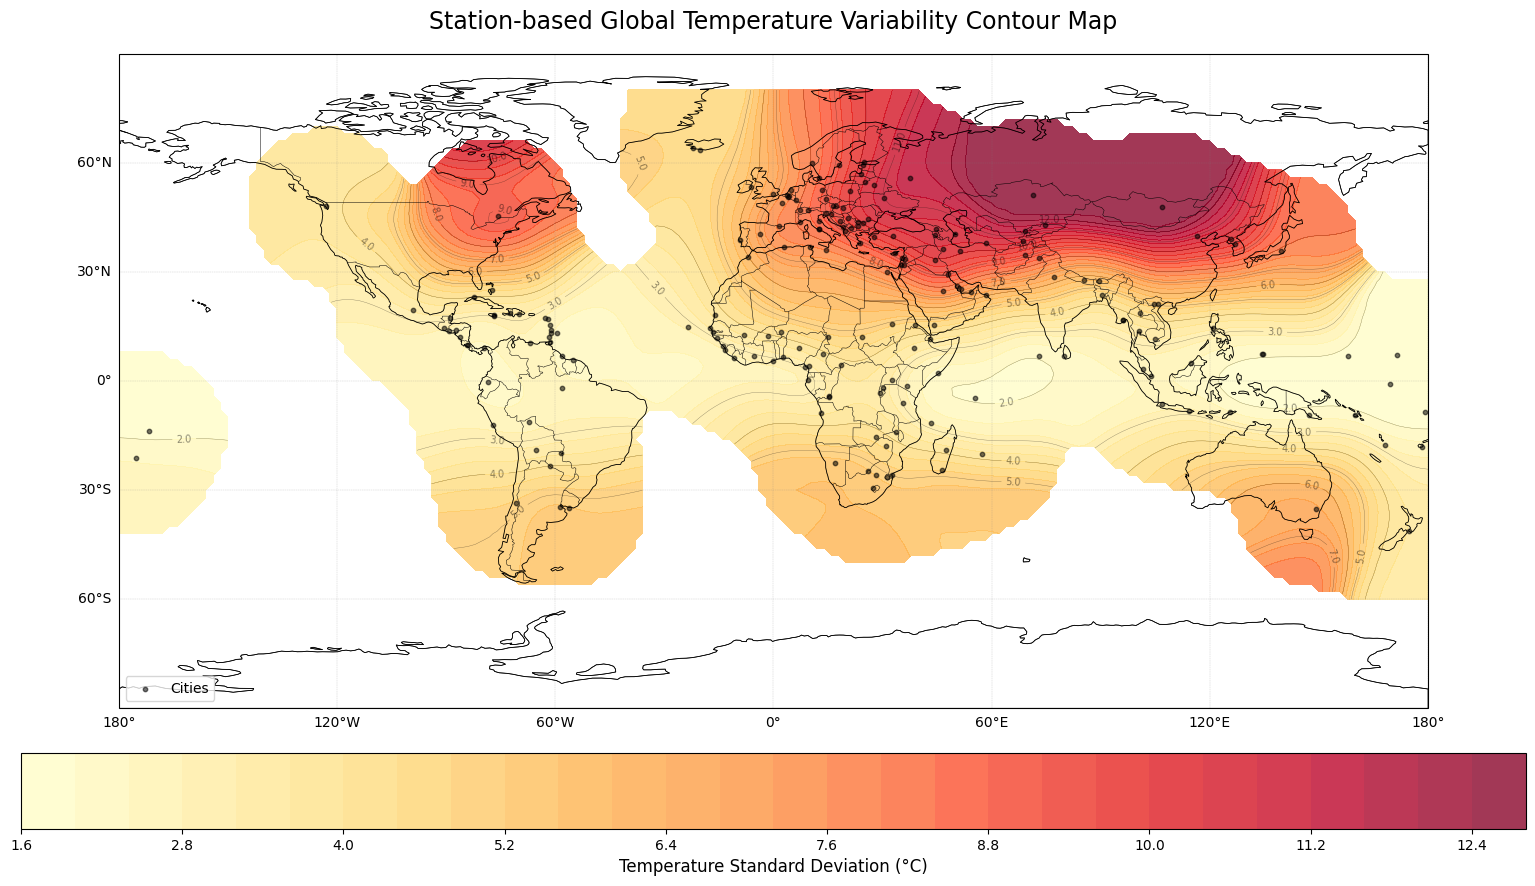

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_temperature_temporal_variability_std_contour_map.png


In [72]:
# temperature temporal variability

plot_contour_world_map(
    data_df=variability_temp_precip_df,
    value_col="temperature_std",
    title="Station-based Global Temperature Variability Contour Map",
    colorbar_label="Temperature Standard Deviation (°C)",
    output_filename="global_temperature_temporal_variability_std_contour_map.png",
    cmap="YlOrRd",
    levels=26,
    grid_res=2.0,
    smooth_sigma=3.0,
    point_color="black"
)

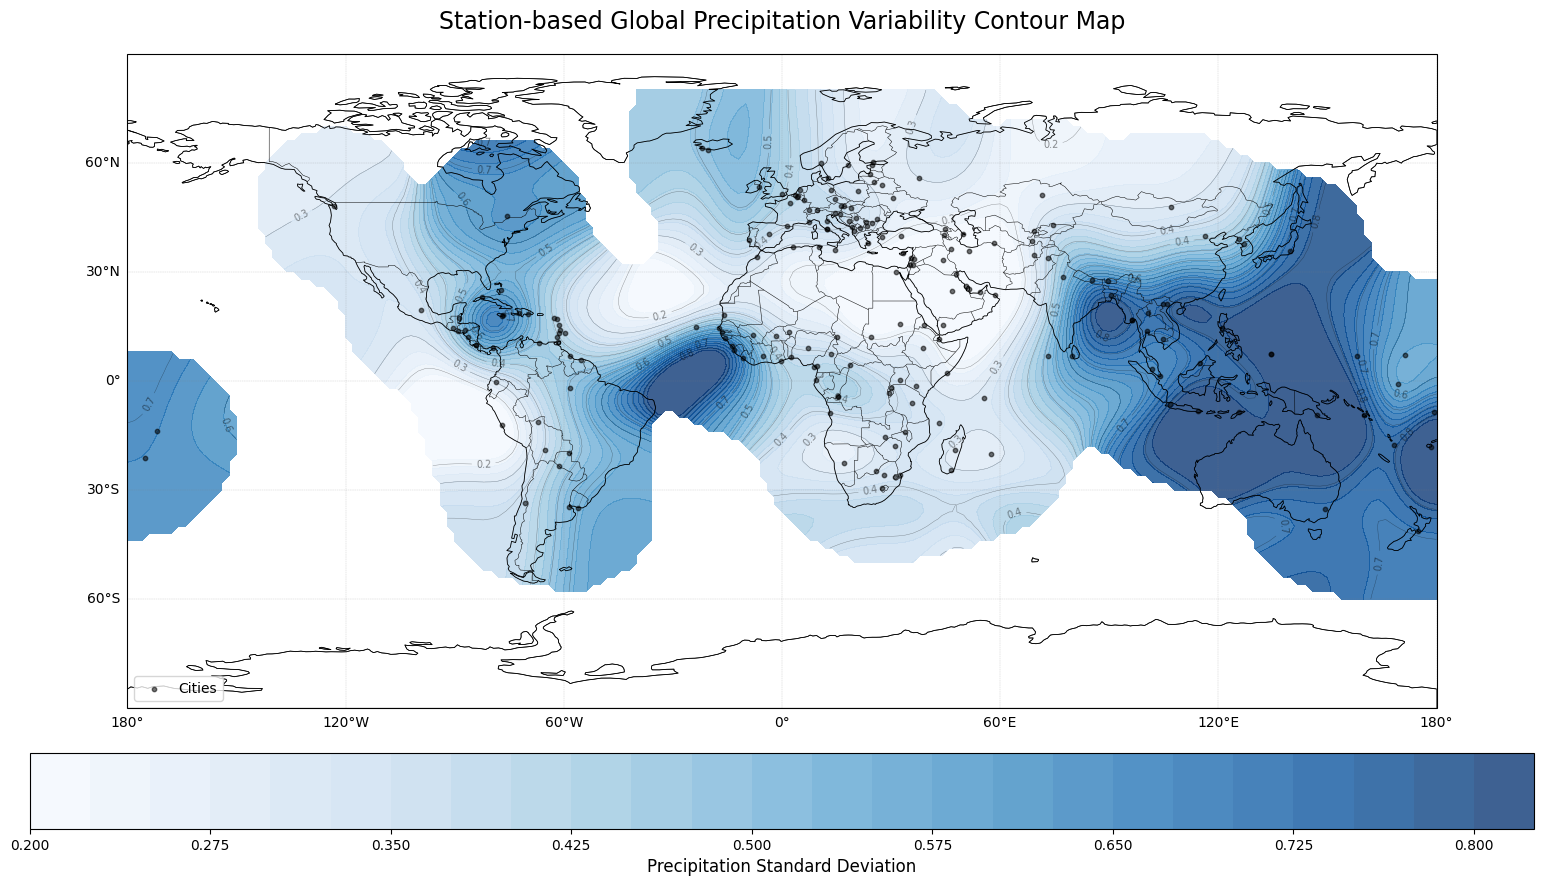

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_precipitation_temporal_variability_std_contour_map.png


In [73]:
# precipitation temporal variability

plot_contour_world_map(
    data_df=variability_temp_precip_df,
    value_col="precipitation_std",
    title="Station-based Global Precipitation Variability Contour Map",
    colorbar_label="Precipitation Standard Deviation",
    output_filename="global_precipitation_temporal_variability_std_contour_map.png",
    cmap="Blues",
    levels=26,
    grid_res=2.0,
    smooth_sigma=3.2,
    point_color="black"
)

In [76]:
# Mean wind_kph, humidity, PM2.5 for all cities

city_mean_extra_df = (
    df_work
    .groupby([country_col, city_col], as_index=False)
    .agg(
        latitude=(lat_original_col, "mean"),
        longitude=(lon_original_col, "mean"),
        mean_wind_kph=(wind_col, "mean"),
        mean_humidity=(humidity_col, "mean"),
        mean_pm25=(pm25_col, "mean"),
        record_count=(temp_col, "count")
    )
)

city_mean_extra_df = city_mean_extra_df.rename(
    columns={
        country_col: "country",
        city_col: "location_name"
    }
)

print("Mean wind/humidity/PM2.5 city data:", city_mean_extra_df.shape)
display(city_mean_extra_df.head())

city_mean_extra_df.to_csv(
    os.path.join(
        VAR_DATA_DIR,
        "city_mean_wind_humidity_pm25.csv"
    ),
    index=False
)

Mean wind/humidity/PM2.5 city data: (270, 8)


,country,location_name,latitude,longitude,mean_wind_kph,mean_humidity,mean_pm25,record_count
0,Afghanistan,Kabul,34.517330,69.182670,8.320055,27.250000,18.715378,728
1,Albania,Tirana,41.327979,19.819111,8.499174,57.539945,14.924077,726
2,Algeria,Algiers,36.762510,3.050486,12.901931,64.863448,18.624207,725
3,Andorra,Andorra La Vella,42.500000,1.517331,8.376616,65.313618,4.708758,727
4,Angola,Luanda,-8.838625,13.233559,9.470564,75.429161,30.428680,727


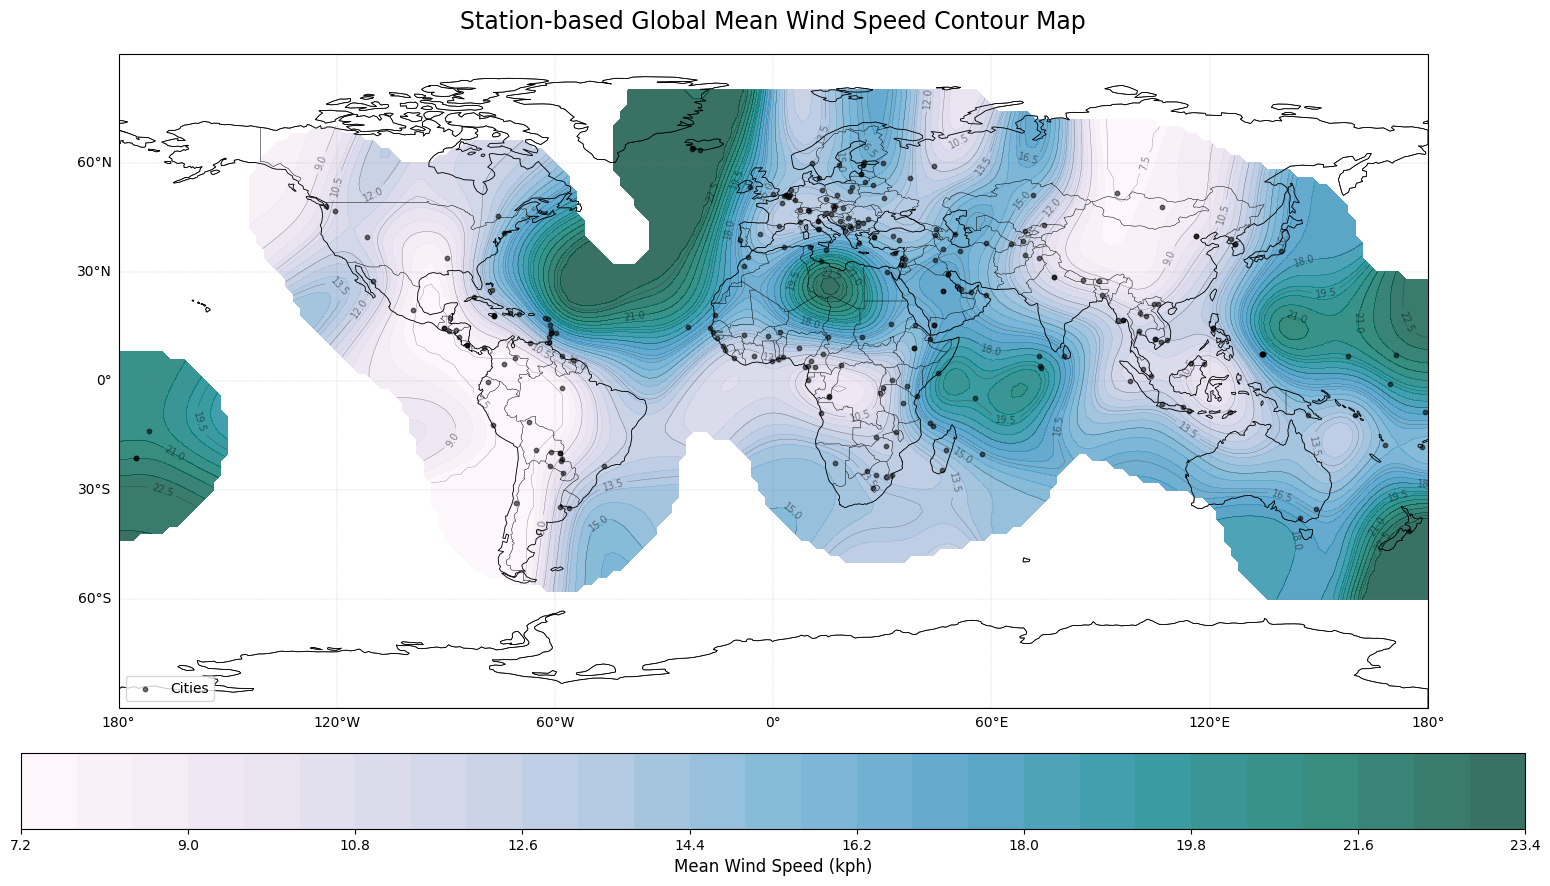

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_mean_wind_kph_contour_map.png


In [78]:
# mean wind_kph

plot_contour_world_map(
    data_df=city_mean_extra_df,
    value_col="mean_wind_kph",
    title="Station-based Global Mean Wind Speed Contour Map",
    colorbar_label="Mean Wind Speed (kph)",
    output_filename="global_mean_wind_kph_contour_map.png",
    cmap="PuBuGn",
    levels=26,
    grid_res=2.0,
    smooth_sigma=3.2,
    point_color="black"
)

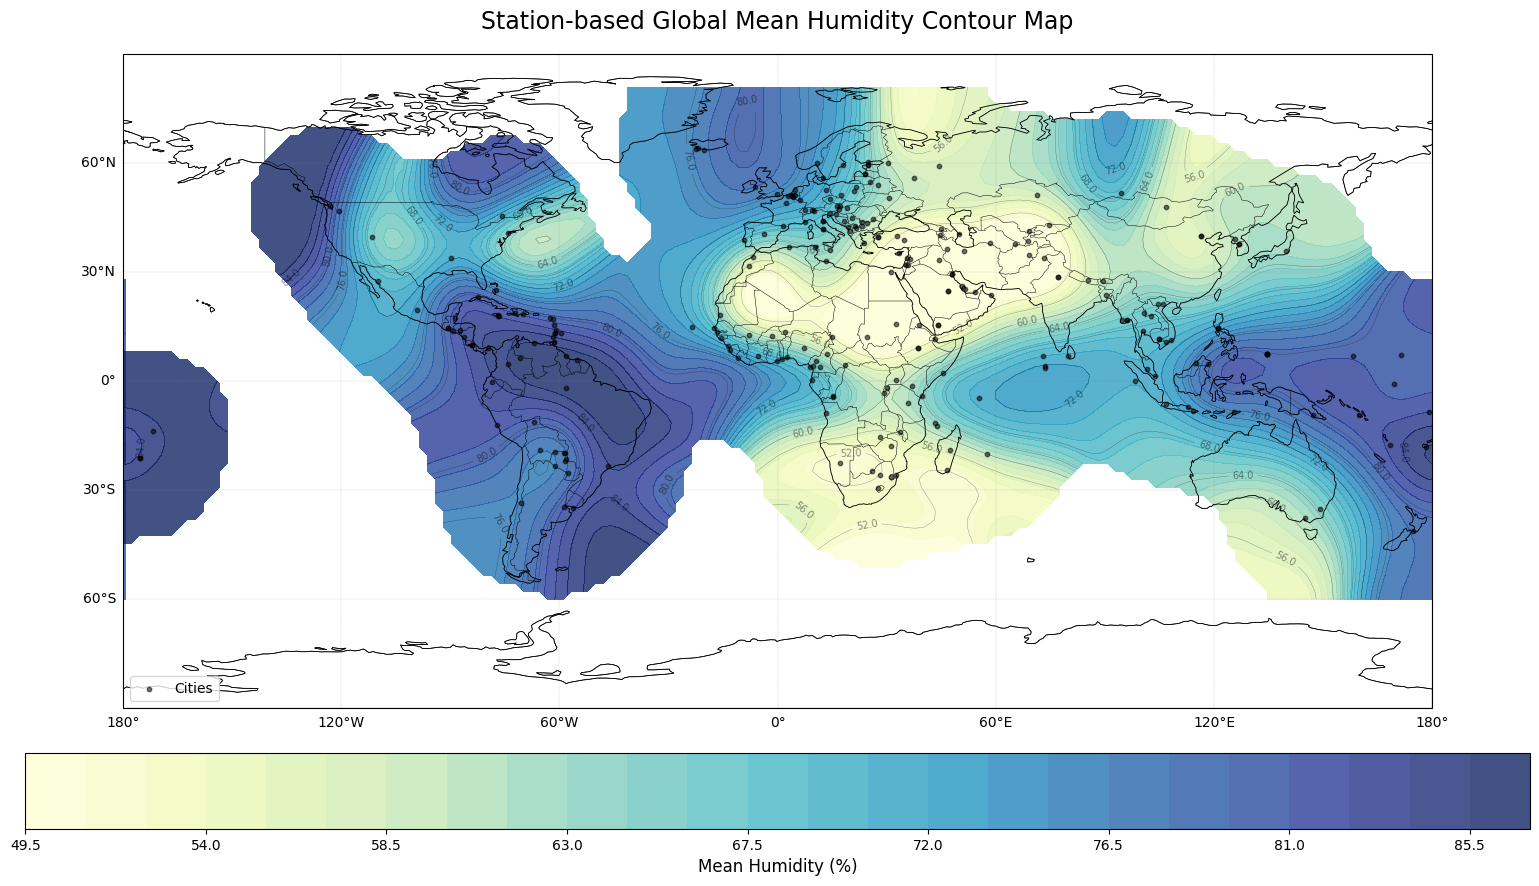

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_mean_humidity_contour_map.png


In [84]:
# mean humidity

plot_contour_world_map(
    data_df=city_mean_extra_df,
    value_col="mean_humidity",
    title="Station-based Global Mean Humidity Contour Map",
    colorbar_label="Mean Humidity (%)",
    output_filename="global_mean_humidity_contour_map.png",
    cmap="YlGnBu",
    levels=26,
    grid_res=2.2,
    smooth_sigma=3.2,
    point_color="black"
)

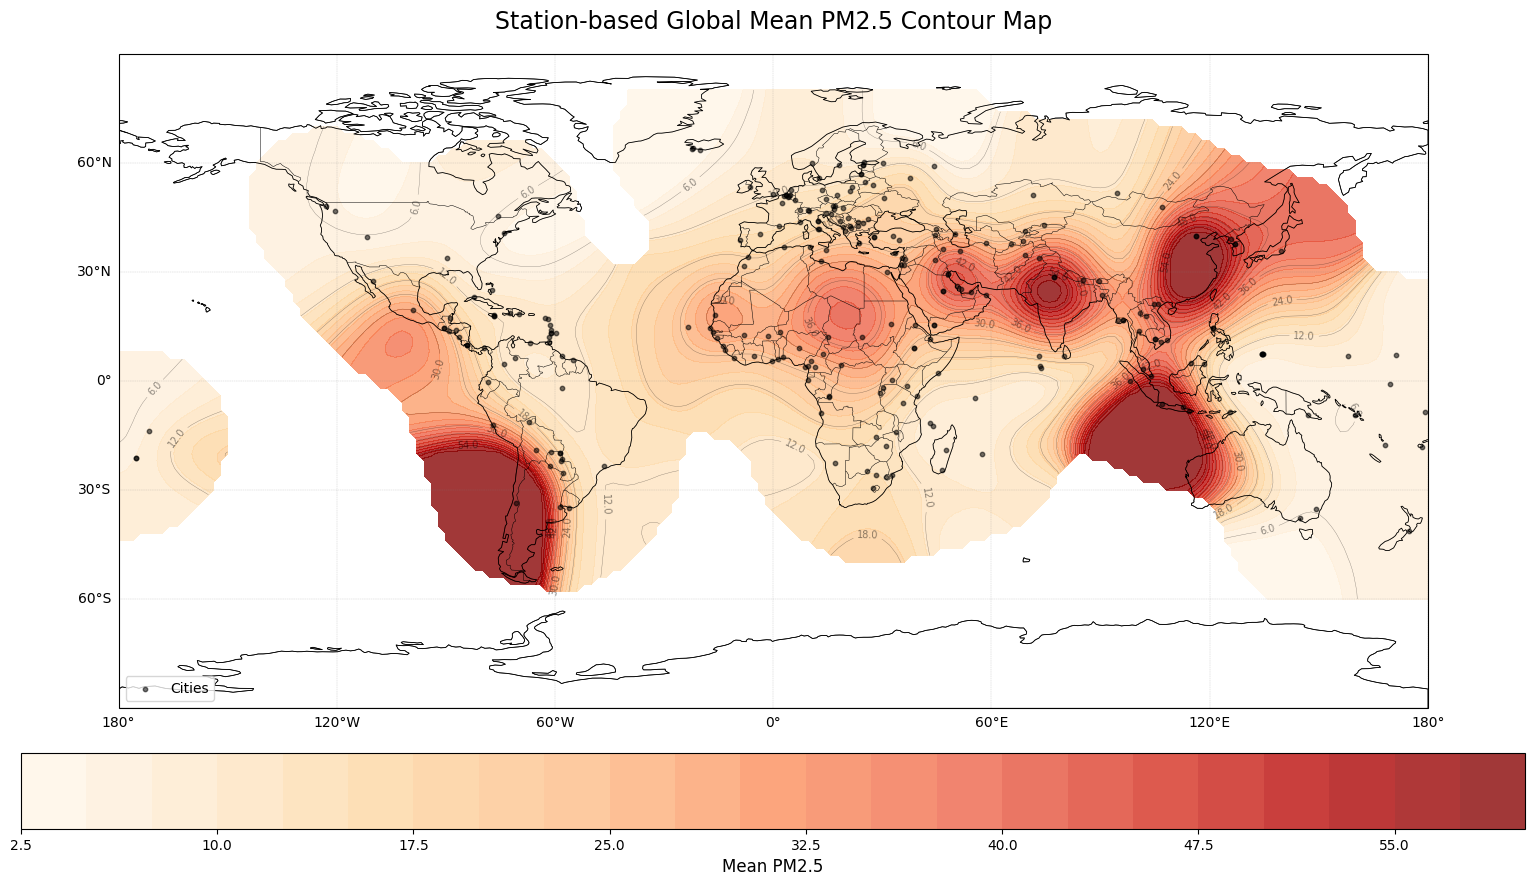

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_mean_pm25_contour_map.png


In [80]:
# mean PM2.5

plot_contour_world_map(
    data_df=city_mean_extra_df,
    value_col="mean_pm25",
    title="Station-based Global Mean PM2.5 Contour Map",
    colorbar_label="Mean PM2.5",
    output_filename="global_mean_pm25_contour_map.png",
    cmap="OrRd",
    levels=26,
    grid_res=2.0,
    smooth_sigma=3.2,
    point_color="black"
)

In [81]:
# Wind, humidity, PM2.5 temporal variability
#     for cities with sequence length > 100

variability_extra_df = (
    df_work
    .groupby([country_col, city_col], as_index=False)
    .agg(
        latitude=(lat_original_col, "mean"),
        longitude=(lon_original_col, "mean"),
        sequence_length=(temp_col, "count"),

        wind_kph_std=(wind_col, "std"),
        wind_kph_var=(wind_col, "var"),
        wind_kph_iqr=(wind_col, iqr_func),

        humidity_std=(humidity_col, "std"),
        humidity_var=(humidity_col, "var"),
        humidity_iqr=(humidity_col, iqr_func),

        pm25_std=(pm25_col, "std"),
        pm25_var=(pm25_col, "var"),
        pm25_iqr=(pm25_col, iqr_func),
        pm25_cv=(pm25_col, cv_func)
    )
)

variability_extra_df = variability_extra_df[
    variability_extra_df["sequence_length"] > 100
].copy()

variability_extra_df = variability_extra_df.rename(
    columns={
        country_col: "country",
        city_col: "location_name"
    }
)

print("Wind/humidity/PM2.5 variability city data:", variability_extra_df.shape)
display(variability_extra_df.head())

variability_extra_df.to_csv(
    os.path.join(
        VAR_DATA_DIR,
        "city_wind_humidity_pm25_variability_gt100.csv"
    ),
    index=False
)

Wind/humidity/PM2.5 variability city data: (205, 15)


,country,location_name,latitude,longitude,sequence_length,wind_kph_std,wind_kph_var,wind_kph_iqr,humidity_std,humidity_var,humidity_iqr,pm25_std,pm25_var,pm25_iqr,pm25_cv
0,Afghanistan,Kabul,34.517330,69.182670,728,6.789820,46.101661,5.8,19.882686,395.321183,22.0,10.762793,115.837720,14.62500,0.574682
1,Albania,Tirana,41.327979,19.819111,726,5.058573,25.589158,5.7,19.380272,375.594954,29.0,8.565260,73.363682,10.66625,0.573527
2,Algeria,Algiers,36.762510,3.050486,725,8.102758,65.654692,10.8,17.585917,309.264477,24.0,13.703513,187.786256,15.54000,0.735283
3,Andorra,Andorra La Vella,42.500000,1.517331,727,4.198679,17.628901,5.8,22.374735,500.628781,39.0,4.050520,16.406710,4.17450,0.859618
4,Angola,Luanda,-8.838625,13.233559,727,4.826133,23.291557,5.8,8.308953,69.038708,10.5,31.208534,973.972604,20.26750,1.024923


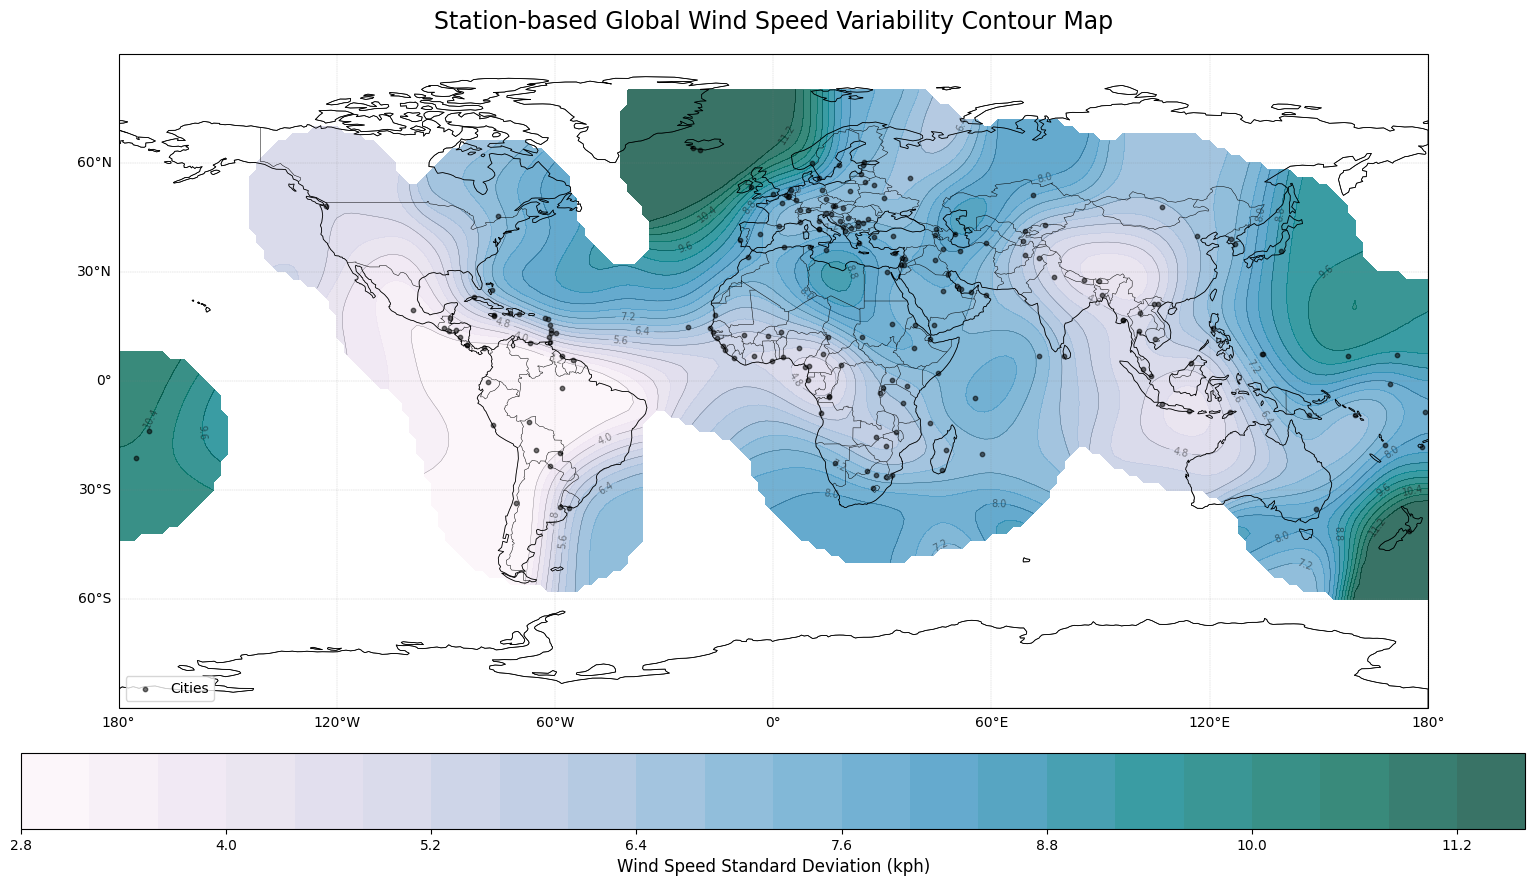

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_wind_kph_temporal_variability_std_contour_map.png


In [83]:
# wind temporal variability

plot_contour_world_map(
    data_df=variability_extra_df,
    value_col="wind_kph_std",
    title="Station-based Global Wind Speed Variability Contour Map",
    colorbar_label="Wind Speed Standard Deviation (kph)",
    output_filename="global_wind_kph_temporal_variability_std_contour_map.png",
    cmap="PuBuGn",
    levels=26,
    grid_res=2.0,
    smooth_sigma=3.2,
    point_color="black"
)

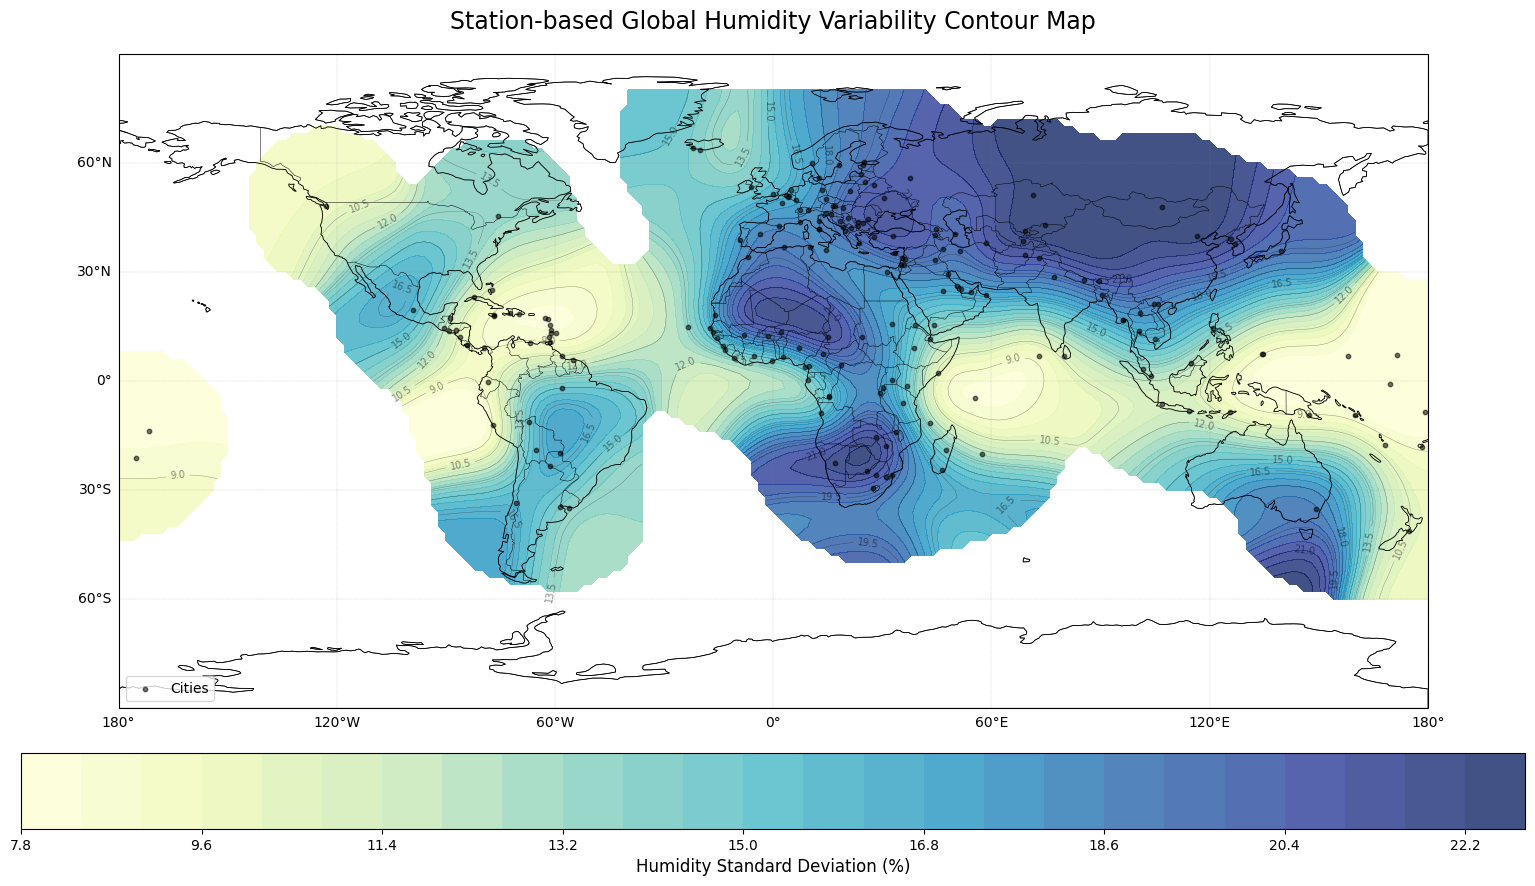

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_humidity_temporal_variability_std_contour_map.png


In [86]:
# humidity temporal variability

plot_contour_world_map(
    data_df=variability_extra_df,
    value_col="humidity_std",
    title="Station-based Global Humidity Variability Contour Map",
    colorbar_label="Humidity Standard Deviation (%)",
    output_filename="global_humidity_temporal_variability_std_contour_map.png",
    cmap="YlGnBu",
    levels=26,
    grid_res=2.0,
    smooth_sigma=3.2,
    point_color="black"
)

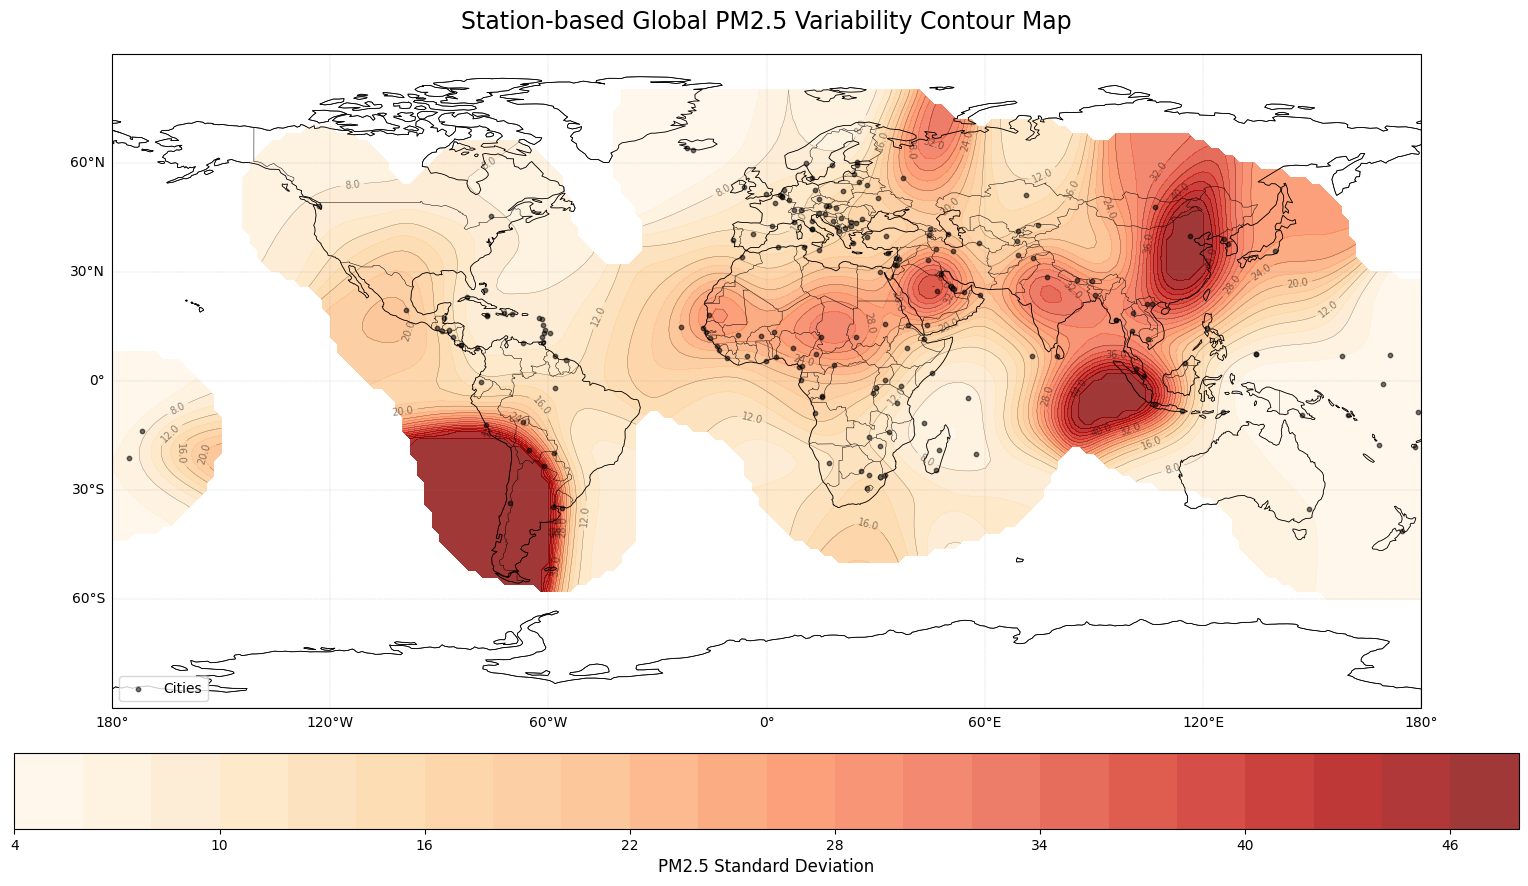

Saved figure:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/figures/global_pm25_temporal_variability_std_contour_map.png


In [87]:
# PM2.5 temporal variability

plot_contour_world_map(
    data_df=variability_extra_df,
    value_col="pm25_std",
    title="Station-based Global PM2.5 Variability Contour Map",
    colorbar_label="PM2.5 Standard Deviation",
    output_filename="global_pm25_temporal_variability_std_contour_map.png",
    cmap="OrRd",
    levels=26,
    grid_res=2.0,
    smooth_sigma=3.2,
    point_color="black"
)

In [88]:
# TOP10 max / min cities for all mean + variability metrics

TOP_DIR = os.path.join(
    VAR_DATA_DIR,
    "top10_statistics"
)

os.makedirs(
    TOP_DIR,
    exist_ok=True
)

stats_df = (
    city_mean_df[
        [
            "country",
            "location_name",
            "mean_temperature_celsius",
            "mean_precipitation"
        ]
    ]
    .merge(
        city_mean_extra_df[
            [
                "country",
                "location_name",
                "mean_wind_kph",
                "mean_humidity",
                "mean_pm25"
            ]
        ],
        on=["country", "location_name"],
        how="outer"
    )
    .merge(
        variability_temp_precip_df[
            [
                "country",
                "location_name",
                "temperature_std",
                "precipitation_std"
            ]
        ],
        on=["country", "location_name"],
        how="outer"
    )
    .merge(
        variability_extra_df[
            [
                "country",
                "location_name",
                "wind_kph_std",
                "humidity_std",
                "pm25_std"
            ]
        ],
        on=["country", "location_name"],
        how="outer"
    )
)

print("Unified statistics shape:")
print(stats_df.shape)
display(stats_df.head())

Unified statistics shape:
(270, 12)


,country,location_name,mean_temperature_celsius,mean_precipitation,mean_wind_kph,mean_humidity,mean_pm25,temperature_std,precipitation_std,wind_kph_std,humidity_std,pm25_std
0,Afghanistan,Kabul,18.858379,0.037074,8.320055,27.250000,18.715378,10.442947,0.229022,6.789820,19.882686,10.762793
1,Albania,Tirana,19.185950,0.140964,8.499174,57.539945,14.924077,9.382668,0.505661,5.058573,19.380272,8.565260
2,Algeria,Algiers,20.196552,0.051724,12.901931,64.863448,18.624207,7.696640,0.211430,8.102758,17.585917,13.703513
3,Andorra,Andorra La Vella,8.647593,0.122435,8.376616,65.313618,4.708758,9.692746,0.387230,4.198679,22.374735,4.050520
4,Angola,Luanda,26.081155,0.034402,9.470564,75.429161,30.428680,2.496182,0.159185,4.826133,8.308953,31.208534


In [89]:
# Metrics list
metric_map = {
    # means
    "mean_temperature_celsius":
        "Mean Temperature",
    "mean_precipitation":
        "Mean Precipitation",
    "mean_wind_kph":
        "Mean Wind Speed",
    "mean_humidity":
        "Mean Humidity",
    "mean_pm25":
        "Mean PM2.5",

    # variability
    "temperature_std":
        "Temperature Variability",
    "precipitation_std":
        "Precipitation Variability",
    "wind_kph_std":
        "Wind Variability",
    "humidity_std":
        "Humidity Variability",
    "pm25_std":
        "PM2.5 Variability"
}

In [90]:
# Save TOP10 max / min
all_results = []
for metric, metric_name in metric_map.items():
    print("\n")
    print("=" * 80)
    print(metric_name)
    print("=" * 80)
    tmp = stats_df[
        [
            "country",
            "location_name",
            metric
        ]
    ].dropna()

    if len(tmp) == 0:
        continue

    #  max
    top10_max = (
        tmp
        .sort_values(
            metric,
            ascending=False
        )
        .head(10).copy()
    )

    top10_max["rank_type"] = "TOP10_MAX"

    #  min
    top10_min = (
        tmp
        .sort_values(
            metric,
            ascending=True
        )
        .head(10).copy()
    )

    top10_min["rank_type"] = "TOP10_MIN"
    print("\nTOP10 MAX")
    display(top10_max)
    print("\nTOP10 MIN")
    display(top10_min)
    save_df = pd.concat([top10_max,top10_min],axis=0)
    save_path = os.path.join(TOP_DIR,f"{metric}_top10.csv")
    save_df.to_csv(save_path,index=False)
    print("Saved:",save_path)
    all_results.append(save_df)



Mean Temperature

TOP10 MAX


,country,location_name,mean_temperature_celsius,rank_type
205,Saudi Arabien,Ar Riyadh,45.000000,TOP10_MAX
121,Kuwait,Kuwait,44.400000,TOP10_MAX
145,Marrocos,Morocco City,40.300000,TOP10_MAX
241,Turkménistan,Krasnyy Turkmenistan,37.800000,TOP10_MAX
267,Турция,Yaren,34.000000,TOP10_MAX
248,United Arab Emirates,Abu Dhabi,32.117744,TOP10_MAX
190,Qatar,Doha,32.103034,TOP10_MAX
230,Thailand,Bangkok,31.847796,TOP10_MAX
38,Cambodia,Phnom Penh,31.843586,TOP10_MAX
158,Myanmar,Rangoon,31.644251,TOP10_MAX



TOP10 MIN


,country,location_name,mean_temperature_celsius,rank_type
192,Russia,Chi-Chi-Erh,-12.490244,TOP10_MIN
225,Switzerland,S-Chanf,0.187500,TOP10_MIN
95,Iceland,Reykjavik,3.427925,TOP10_MIN
153,Mongolia,Ulaanbaatar,3.824931,TOP10_MIN
44,Canada,Ottawa,4.838069,TOP10_MIN
96,Iceland,Vestmannaeyjar,6.422642,TOP10_MIN
92,Hungary,Bogot,6.985185,TOP10_MIN
168,Norway,Oslo,7.804552,TOP10_MIN
20,Belgium,'S-Gravenbrakel,8.222034,TOP10_MIN
115,Kazakhstan,Astana,8.304683,TOP10_MIN


Saved: /content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/data/variability_analysis/top10_statistics/mean_temperature_celsius_top10.csv


Mean Precipitation

TOP10 MAX


...

Saved: /content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/data/variability_analysis/top10_statistics/humidity_std_top10.csv


PM2.5 Variability

TOP10 MAX


,country,location_name,pm25_std,rank_type
48,Chile,Santiago,223.725157,TOP10_MAX
204,Saudi Arabia,Riyadh,117.166860,TOP10_MAX
100,Indonesia,Jakarta,111.457010,TOP10_MAX
49,China,Beijing,86.677699,TOP10_MAX
98,India,New Delhi,59.550770,TOP10_MAX
14,Bangladesh,Dhaka,58.201532,TOP10_MAX
147,Mauritania,Nouakchott,57.229522,TOP10_MAX
122,Kuwait,Kuwait City,52.232615,TOP10_MAX
259,Vietnam,Hanoi,50.917924,TOP10_MAX
166,Nigeria,Abuja,43.229506,TOP10_MAX



TOP10 MIN


,country,location_name,pm25_std,rank_type
95,Iceland,Reykjavik,1.601989,TOP10_MIN
213,Solomon Islands,Honiara,2.330289,TOP10_MIN
96,Iceland,Vestmannaeyjar,2.956165,TOP10_MIN
173,Palau,Koror,3.090631,TOP10_MIN
76,Fiji Islands,Suva,3.918222,TOP10_MIN
176,Papua New Guinea,Port Moresby,4.001011,TOP10_MIN
163,New Zealand,Wellington,4.022188,TOP10_MIN
3,Andorra,Andorra La Vella,4.050520,TOP10_MIN
201,Samoa,Apia,4.079903,TOP10_MIN
148,Mauritius,Port Louis,4.197495,TOP10_MIN


Saved: /content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/data/variability_analysis/top10_statistics/pm25_std_top10.csv


In [91]:
# Save global summary
summary_df = pd.concat(
    all_results,
    axis=0)
summary_path = os.path.join(
    TOP_DIR,
    "ALL_METRICS_TOP10_SUMMARY.csv")
summary_df.to_csv(summary_path,index=False)
print("Saved global summary:")
print(summary_path)
display(summary_df.head(30))

Saved global summary:
/content/drive/MyDrive/Weather Trend Forecasting/eda_outputs/global_temperature_precipitation_contours/data/variability_analysis/top10_statistics/ALL_METRICS_TOP10_SUMMARY.csv


,country,location_name,mean_temperature_celsius,rank_type,mean_precipitation,mean_wind_kph,mean_humidity,mean_pm25,temperature_std,precipitation_std,wind_kph_std,humidity_std,pm25_std
205,Saudi Arabien,Ar Riyadh,45.000000,TOP10_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
121,Kuwait,Kuwait,44.400000,TOP10_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,Marrocos,Morocco City,40.300000,TOP10_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
241,Turkménistan,Krasnyy Turkmenistan,37.800000,TOP10_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,Турция,Yaren,34.000000,TOP10_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
248,United Arab Emirates,Abu Dhabi,32.117744,TOP10_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,Qatar,Doha,32.103034,TOP10_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
230,Thailand,Bangkok,31.847796,TOP10_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,Cambodia,Phnom Penh,31.843586,TOP10_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
158,Myanmar,Rangoon,31.644251,TOP10_MAX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
